In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib as mpl
from matplotlib import pyplot as plt
import pymc as pm

from IPython.core.pylabtools import figsize
mpl.style.use('ggplot')


In [2]:
count_data = np.loadtxt('../Chapter1_Introduction/data/txtdata.csv')
n = len(count_data)
n

74

<BarContainer object of 74 artists>

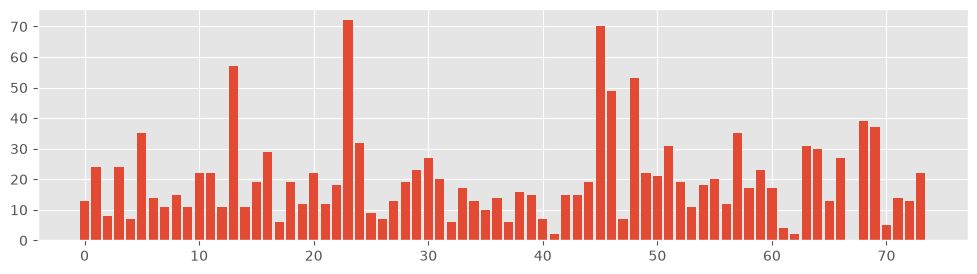

In [3]:
figsize(12,3)
plt.bar(np.arange(n), count_data)

- Distribution of C, count of text messages per day, for prior distribution use Poisson with parameter lambda $\lambda$
- Assume there's an increase over time, and there's a change or 'switchpoint' tau $\tau$ .. so we have one Poisson for the "before change" and one for "after change" each with it's own lambda.
- the two lambdas themselves need prior distributions, use Exponential with parameter alpha $\alpha$
- "A good rule of thumb is to set the exponential parameter equal to the inverse of the average of the count data."  -- __why, experiement__
- "An alternative, and something I encourage the reader to try, would be to have two priors: one for each (before and after changepoint). Creating two exponential distributions with different values reflects our prior belief that the rate changed at some point during the observations."  -- __ok, why aren't we doing this now, just to keep simple?__ 
- Returning to the switchpoint, we need a prior distribution to estimate when tau may have occurred.  Since data is noisy and we don't have an obvious starting point, use Discrete Uniform to have an equal probability over all 70 days observed.  $P=1/70$
- So essentially this is a big simulation (click)

PYMC links

- https://www.pymc.io/projects/docs/en/v5.4.0/api.html
- https://www.pymc.io/projects/docs/en/v5.4.0/api/generated/pymc.Model.html

Distributions

- https://www.pymc.io/projects/docs/en/latest/api/distributions/generated/pymc.Poisson.html discrete (!)
- https://www.pymc.io/projects/docs/en/v5.4.0/api/distributions/generated/pymc.Exponential.html  continuous

Samplers
 
- https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html base function to manage sampling .. returns a trace object
- https://www.pymc.io/projects/docs/en/v5.4.0/api/generated/pymc.Metropolis.html metropolis-hastings sampling step
- https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm this is an MCMC samping algorithm
- https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.backends.base.MultiTrace.html#pymc.backends.base.MultiTrace one of the formats for Trace / MCMC results

Math/Tensors

- https://www.pymc.io/projects/docs/en/v5.4.0/api/distributions/generated/pymc.DiscreteUniform.html discrete
- https://www.pymc.io/projects/docs/en/v5.4.0/api/math.html math functions, mostly coming from pytensor.tensor
- https://pytensor.readthedocs.io/en/latest/ for ref
- https://www.pymc.io/projects/docs/en/v5.4.0/api/generated/pymc.math.switch.html an if/then for tensor operations, `if cond then ift else iff`

Other

- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html







In [4]:
with pm.Model() as model:
  alpha = 1.0 / count_data.mean() # rule of thumb, using same for both Exps
  lambda_1 = pm.Exponential('lambda_1', alpha) # rng using Exponential dist "before switchpoint"
  lambda_2 = pm.Exponential('lambda_2', alpha) # "after switchpoint" (using same alpha)
  tau = pm.DiscreteUniform('tau', lower=0, upper=n-1) # uniform probabilities over the range of obs


In [5]:
with model:
    idx = np.arange(n)
    lambda_ = pm.math.switch(tau > idx, lambda_1, lambda_2) # function, apply the Exp parameter for before/after switchpoint


In [6]:
with model:
    observation = pm.Poisson('obs', lambda_, observed = count_data)

In [7]:
# runs a MCMC, gets thousands of samples from posterior distributions of the two lambdas and tau.

with model:
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=False)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [lambda_1]
>Metropolis: [lambda_2]
>Metropolis: [tau]


Output()

Sampling 4 chains for 5_000 tune and 10_000 draw iterations (20_000 + 40_000 draws total) took 2 seconds.


In [8]:
lambda_1_samples = trace['lambda_1']
lambda_2_samples = trace['lambda_2']
tau_samples = trace['tau']

(1.0, 73.0)

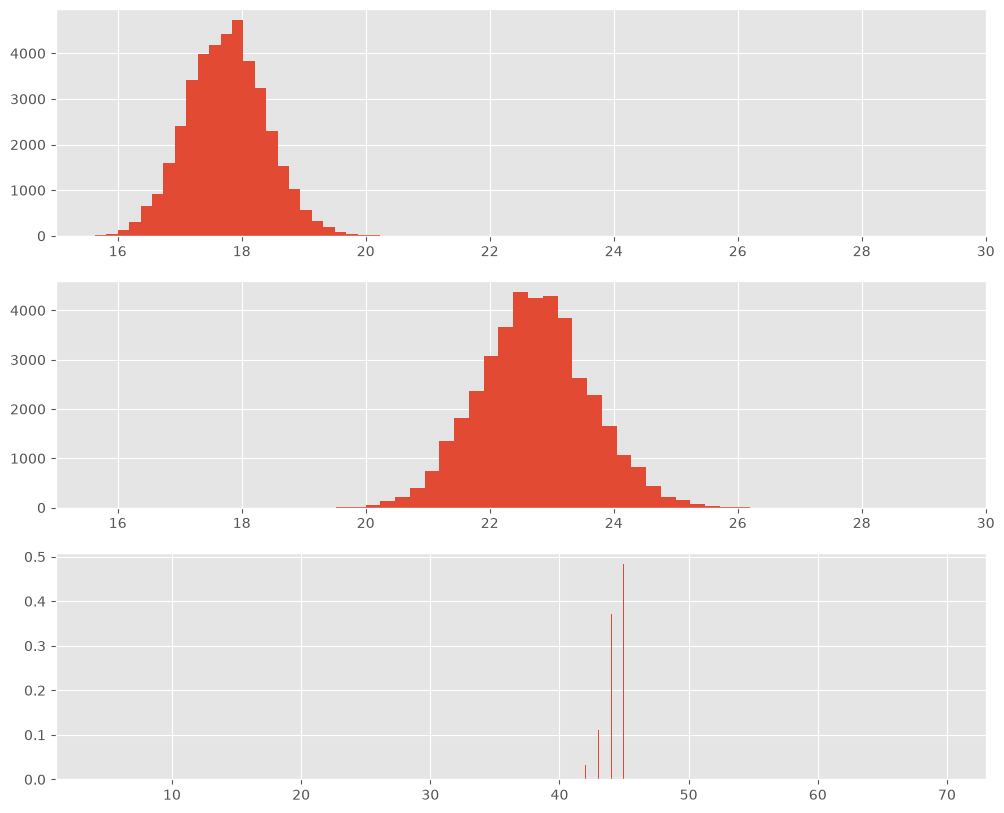

In [9]:
figsize(12,10)

ax = plt.subplot(311)
plt.hist(lambda_1_samples, bins=30)
plt.xlim([15, 30])

ax = plt.subplot(312)
plt.hist(lambda_2_samples, bins=30)
plt.xlim([15, 30])

ax = plt.subplot(313)
w = 1 / tau_samples.shape[0] * np.ones_like(tau_samples)
plt.hist(tau_samples, bins=n, weights=w)
plt.xlim([1, n-1])

- posterior distribution for tau: likely switchpoints around Day 43-45 (50% on Day 45)
- before switchpoint, mean lambda 18 texts/day frequency
- after switchpoint, mean lambda 23 texts/day frequency
- clear difference between the two lambda posterior distributions suggest a significant change in frequency.
- note the sample posterior distributions are normal, though they were sampled from Expos (expected behavior)

In [10]:
# Q: What is the expected number of texts at day t?

# the expected value of a Poisson variable is equal to its lambda (see stats notes)
# so question is "what is the value of lambda at time t?"



In [51]:
N = tau_samples.shape[0] # 40000 samples
exp_texts_per_day = np.zeros(n)

In [56]:

 # initialize empty array of 74 days

# recall that tau_samples is a table of 40000 observations ranging from 42-45

for day in range(0, n):
    ix = day < tau_samples # boolean index of each day 0 to 74, how many of the 40000 samples were before the switchpoint ('True')
    exp_texts_per_day[day] = (lambda_1_samples[ix].sum() + lambda_2_samples[~ix].sum()) / N # array-based sums .. 
    

In [ ]:
# see it in action
for d in range(40,46):
    ix = d < tau_samples
    print(lambda_1_samples[ix].sum()/N, lambda_2_samples[~ix].sum()/N)

17.749011354924903 0.0032471765769936764
17.736300591454516 0.01851293433572642
17.138561295062484 0.7599432348906413
15.174032737079777 3.242646156621302
8.59683784376063 11.66653751086964
0.0 22.721157001786285


<BarContainer object of 74 artists>

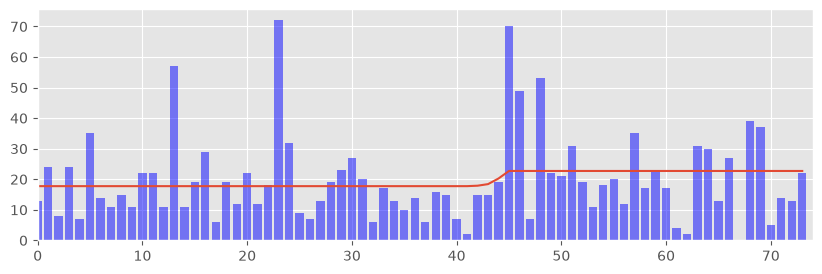

In [71]:
figsize(10,3)
plt.plot(range(n), exp_texts_per_day)
plt.xlim(0, n)
plt.bar(np.arange(n), count_data, color='blue', alpha=0.5)


In [81]:
# 1.  Using `lambda_1_samples` and `lambda_2_samples`, what is the mean of the posterior distributions of $\lambda_1$ and $\lambda_2$?
print(lambda_1_samples.mean(), lambda_2_samples.mean())

17.751873309157407 22.721157001786285


In [ ]:
# 2. What is the expected percentage increase in text-message rates? (note correct solution is array-based)
((lambda_2_samples-lambda_1_samples)/lambda_1_samples).mean()

np.float64(0.28155644980395655)

In [ ]:
# What is the mean of $\lambda_1$ **given** that we know $\tau$ is less than 45?
lambda_1_samples_updated = lambda_1_samples < 45
lambda_1_samples_updated.sum()/N

# ??  come back for review

np.float64(1.0)